In [103]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")

Libraries imported successfully.


In [104]:
from pathlib import Path

data_path = Path("../data/processed/customerIQ_customer_churn_features.csv")

df = pd.read_csv(data_path)

print("Data loaded successfully.")
print("Shape:", df.shape)

Data loaded successfully.
Shape: (10000, 20)


In [105]:
print(df.head())

  customer_id   age  gender location  tenure_months  monthly_spend  \
0     C100000  56.0  Female   Mumbai             40        1008.23   
1     C100001  69.0    Male    Delhi             31        1716.53   
2     C100002  46.0  Female   Mumbai             65        1035.82   
3     C100003  32.0    Male    Other             39        2622.21   
4     C100004  60.0    Male     Pune             24        2117.73   

   total_spend  login_frequency  support_tickets  product_usage  \
0     43296.89             20.0                1           68.0   
1     52968.01             20.0                3           87.0   
2     72203.52             23.0                7           88.0   
3    107971.82             13.0                1           68.0   
4     49767.32              4.0                2           80.0   

  subscription_type payment_method  discount_used  churn  \
0           Monthly     Debit Card              1      0   
1           Monthly            UPI              0      0

In [106]:
print(df.dtypes)

customer_id                    str
age                        float64
gender                         str
location                       str
tenure_months                int64
monthly_spend              float64
total_spend                float64
login_frequency            float64
support_tickets              int64
product_usage              float64
subscription_type              str
payment_method                 str
discount_used                int64
churn                        int64
customer_lifetime_value    float64
average_monthly_spend      float64
usage_per_month            float64
support_ticket_rate        float64
age_group                      str
tenure_group                   str
dtype: object


In [107]:
categorical_features = [
    "gender",
    "location",
    "subscription_type",
    "payment_method",
    "age_group",
    "tenure_group"
]

print("Categorical features:")
print(categorical_features)

Categorical features:
['gender', 'location', 'subscription_type', 'payment_method', 'age_group', 'tenure_group']


In [108]:
numerical_features = [
    "age",
    "tenure_months",
    "monthly_spend",
    "total_spend",
    "login_frequency",
    "support_tickets",
    "product_usage",
    "discount_used",
    "average_monthly_spend",
    "usage_per_month",
    "support_ticket_rate"
]

print("Numerical features:")
print(numerical_features)

Numerical features:
['age', 'tenure_months', 'monthly_spend', 'total_spend', 'login_frequency', 'support_tickets', 'product_usage', 'discount_used', 'average_monthly_spend', 'usage_per_month', 'support_ticket_rate']


In [109]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

print("Preprocessing tools imported successfully.")

Preprocessing tools imported successfully.


In [110]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

print("Transformers created successfully.")

Transformers created successfully.


In [111]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [112]:
predictor_features = numerical_features + categorical_features

X = df[predictor_features]

y = df["churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 17)
y shape: (10000,)


In [113]:
print("Churn counts:")
print(y.value_counts())

print("\nChurn percentages:")
print(y.value_counts(normalize=True))

Churn counts:
churn
0    9743
1     257
Name: count, dtype: int64

Churn percentages:
churn
0    0.9743
1    0.0257
Name: proportion, dtype: float64


In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 17)
Testing data: (2000, 17)


In [115]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training preprocessing completed.")
print("Processed training shape:", X_train_processed.shape)

print("Testing preprocessing completed.")
print("Processed testing shape:", X_test_processed.shape)

Training preprocessing completed.
Processed training shape: (8000, 38)
Testing preprocessing completed.
Processed testing shape: (2000, 38)


In [116]:
print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

print("\nProcessed data type:")
print(type(X_train_processed))

Training shape: (8000, 38)
Testing shape: (2000, 38)

Processed data type:
<class 'numpy.ndarray'>


In [117]:
from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported successfully.")

Logistic Regression imported successfully.


In [118]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

print("Logistic Regression model created.")

Logistic Regression model created.


In [119]:
logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [120]:
y_pred_logistic = logistic_model.predict(
    X_test_processed
)

print("Logistic Regression predictions completed.")
print("Number of predictions:", len(y_pred_logistic))

Logistic Regression predictions completed.
Number of predictions: 2000


In [121]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.7015
Precision: 0.048013245033112585
Recall   : 0.5686274509803921
F1 Score : 0.08854961832061069


In [122]:
from sklearn.metrics import confusion_matrix

logistic_cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Confusion Matrix:")
print(logistic_cm)

Logistic Regression Confusion Matrix:
[[1374  575]
 [  22   29]]


In [123]:
from sklearn.tree import DecisionTreeClassifier

print("Decision Tree imported successfully.")

Decision Tree imported successfully.


In [124]:
decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

print("Decision Tree model created.")

Decision Tree model created.


In [125]:
decision_tree_model.fit(
    X_train_processed,
    y_train
)

print("Decision Tree training completed.")

Decision Tree training completed.


In [126]:
y_pred_tree = decision_tree_model.predict(
    X_test_processed
)

print("Decision Tree predictions completed.")
print("Number of predictions:", len(y_pred_tree))

Decision Tree predictions completed.
Number of predictions: 2000


In [127]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_precision = precision_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1 Score :", tree_f1)

Decision Tree Results
--------------------
Accuracy : 0.951
Precision: 0.0392156862745098
Recall   : 0.0392156862745098
F1 Score : 0.0392156862745098


In [128]:
tree_cm = confusion_matrix(
    y_test,
    y_pred_tree
)

print("Decision Tree Confusion Matrix:")
print(tree_cm)

Decision Tree Confusion Matrix:
[[1900   49]
 [  49    2]]


In [129]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully.")

Random Forest imported successfully.


In [130]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created.")

Random Forest model created.


In [131]:
random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [132]:
y_pred_forest = random_forest_model.predict(
    X_test_processed
)

print("Random Forest predictions completed.")
print("Number of predictions:", len(y_pred_forest))

Random Forest predictions completed.
Number of predictions: 2000


In [133]:
forest_accuracy = accuracy_score(
    y_test,
    y_pred_forest
)

forest_precision = precision_score(
    y_test,
    y_pred_forest,
    zero_division=0
)

forest_recall = recall_score(
    y_test,
    y_pred_forest,
    zero_division=0
)

forest_f1 = f1_score(
    y_test,
    y_pred_forest,
    zero_division=0
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", forest_accuracy)
print("Precision:", forest_precision)
print("Recall   :", forest_recall)
print("F1 Score :", forest_f1)

Random Forest Results
---------------------
Accuracy : 0.9745
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [134]:
forest_cm = confusion_matrix(
    y_test,
    y_pred_forest
)

print("Random Forest Confusion Matrix:")
print(forest_cm)

Random Forest Confusion Matrix:
[[1949    0]
 [  51    0]]


In [135]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        forest_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        forest_recall
    ],
    "F1 Score": [
        logistic_f1,
        tree_f1,
        forest_f1
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.7015   0.048013  0.568627  0.088550
1        Decision Tree    0.9510   0.039216  0.039216  0.039216
2        Random Forest    0.9745   0.000000  0.000000  0.000000


In [136]:
best_recall_model = results.loc[
    results["Recall"].idxmax()
]

print("Model with the highest recall:")
print(best_recall_model)

Model with the highest recall:
Model        Logistic Regression
Accuracy                  0.7015
Precision               0.048013
Recall                  0.568627
F1 Score                 0.08855
Name: 0, dtype: object


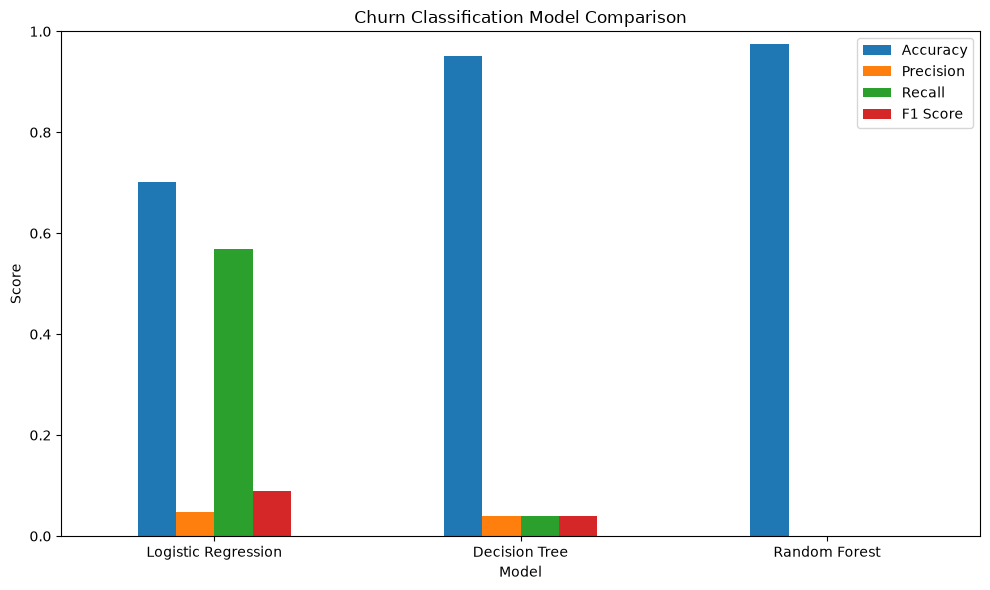

In [137]:
import matplotlib.pyplot as plt

results_plot = results.set_index("Model")

results_plot[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Churn Classification Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

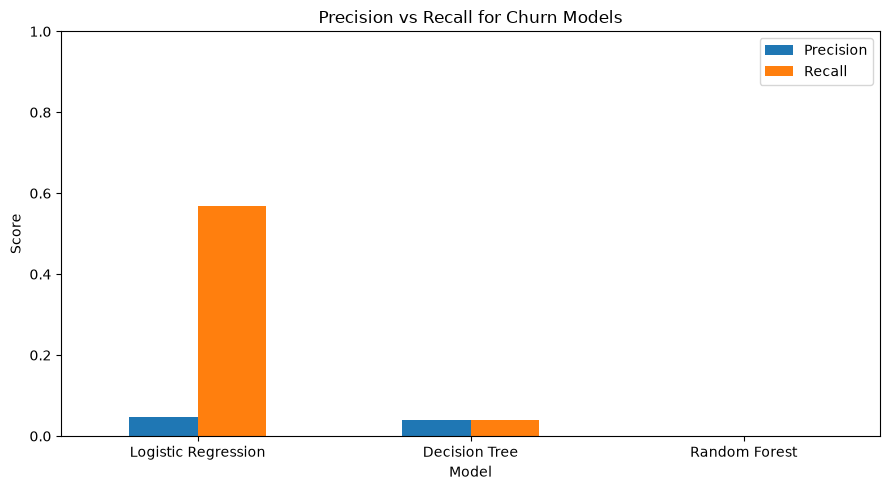

In [138]:
precision_recall = results.set_index("Model")[
    ["Precision", "Recall"]
]

precision_recall.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Precision vs Recall for Churn Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [139]:
print("Logistic Regression:")
print(logistic_cm)

print("\nDecision Tree:")
print(tree_cm)

print("\nRandom Forest:")
print(forest_cm)

Logistic Regression:
[[1374  575]
 [  22   29]]

Decision Tree:
[[1900   49]
 [  49    2]]

Random Forest:
[[1949    0]
 [  51    0]]


In [140]:
best_f1_model = results.loc[
    results["F1 Score"].idxmax()
]

print("Best model based on F1 Score:")
print(best_f1_model)

Best model based on F1 Score:
Model        Logistic Regression
Accuracy                  0.7015
Precision               0.048013
Recall                  0.568627
F1 Score                 0.08855
Name: 0, dtype: object


In [141]:
results.to_csv("../data/processed/classification_results.csv", index=False)

In [142]:
classification_results = pd.read_csv("../data/processed/classification_results.csv")
classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7015,0.048013,0.568627,0.088550
1,Decision Tree,0.9510,0.039216,0.039216,0.039216
2,Random Forest,0.9745,0.000000,0.000000,0.000000
